In [1]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.model_selection import GridSearchCV
import seaborn as sns

from lightgbm import LGBMRegressor, LGBMClassifier
from causalml.inference.meta import BaseXRegressor, BaseSRegressor, BaseTRegressor

import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
survey = pd.read_csv(r"C:\Users\Peter\OneDrive\Desktop\Code and Projects\ECO1465\clean survey.csv")

In [4]:
survey

,Unnamed: 0,ResponseId,treatment,matchTreatment,treatIdeo,control,potentialText,primaryOutlets,comply,newLikesNum,tookFollowup,have14DaysPosts,installTwoWeeks,have14DaysLikes,validExtAndShared,validHisOneWeek,minHistoryRelative,maxTimeExt,maxDiffPostsDay,mobile,politicsAd,follow,followAboveMed,thermo_Rep,thermo_Dem,empathy_Rep,empathy_Dem,certain,certainAboveEqMed,selfReportedLikesNum,slant_Rep,slant_Dem,zipReside,registered,personality_1,personality_2,personality_3,personality_4,personality_5,personality_6,personality_7,personality_8,personality_9,personality_10,immigration,daca,immigrationWorry,thermo_Trump,thermo_TrumpHave,thermo_TrumpWM,thermo_Local,mostNews,mostNewsSM,accessWebsites,crtA,crtB,ideoLeaning,ideoLeaningF,startPOSIX,democrat,republican,independent,ideologyN,thermo_Diff,thermo_DiffAboveEqMed,thermo_DiffHave,thermo_DiffWM,age,ageAboveMed,ageHave,ageWM,female,ideologyF,partyAllF,trumpF,genderF,ageSqWM,immigrationWorryF,MuellerFairF,obstructF,repF,absIdeology,empathyDifficult_Diff,empathyDifficult_DiffHave,empathyDifficult_DiffWM,echoChamber,echoChamberAboveEqMed,openessPersonality,openessPersonalityAboveEqMed,seenCounterAnyShare,seenCounterAnyShareAboveEqMed,initialLikesNum,countInitialNewsLikes,countInitialNewsLikesAboveMed,meanInitialSlant,absInitialSlant,postsInitialAccess,absIdeoAboveEqMed,meanSeenAboveMed,meanDistSlantUnderMed,consIdeology,crtScoreAboveEqMed,clickLinks_Mobile,clickLinks_PC,party7,genericBallotF,thermo_Own,thermo_Opposing,empathyDifficult_Own,empathyDifficult_Opposing,objective,voteSupport2016F,ageSq,rosensteinF,Q_SocialSource,askExtension,F_approve,F_approve_ScaleS,F_favorable_McCabe,F_favorable_McCabe_Op_ScaleS,F_favorable_Hogg,F_favorable_Hogg_Op_ScaleS,F_favorable_Mueller,F_favorable_Mueller_Op_ScaleS,F_favorable_Daniels,F_favorable_Daniels_Op_ScaleS,F_favorable_Bolton,F_favorable_Bolton_Op_ScaleS,F_favorable_Pruitt,F_favorable_Pruitt_Op_ScaleS,F_favorable_Cohen,F_favorable_Cohen_Op_ScaleS,F_favorable_Clinton,F_favorable_Clinton_Op_ScaleS,F_favOrg_NRA,F_favOrg_NRA_Op_ScaleS,F_favOrg_March,F_favOrg_March_Op_ScaleS,F_favOrg_California,F_favOrg_California_Op_ScaleS,F_favOrg_FBI,F_favOrg_FBI_Op_ScaleS,F_mccabe_summary,F_mccabe_summary_ScaleS,F_tradeWar,F_tradeWar_Op_ScaleS,F_gunPolicy_Assault,F_gunPolicy_Assault_Op_ScaleS,F_thermo_Trump,F_thermo_Trump_ScaleS,F_favOrg_Immigrants,F_favOrg_Immigrants_Op_ScaleS,F_investigation,F_investigation_Op_ScaleS,F_BN_Obstruct,F_BN_Obstruct_Op_ScaleS,F_partyIdeasDem,F_partyIdeasRep,F_empathy_difficultDem,F_empathy_difficultRep,F_empathy_importantDem,F_empathy_importantRep,F_thermo_Dem,F_thermo_Rep,F_marryDem,F_marryRep,persIndex,persAnderson,persAndersonNoNeg,persAndersonWithMissing,persAndersonNoNegWithMissing,F_thermo_Diff,F_thermo_DiffScale,F_empathyDifficult_Diff,F_empathyDifficult_DiffScale,F_empathyImportant_Diff,F_empathyImportant_DiffScale,F_partyIdeas_Diff,F_partyIdeas_DiffScale,F_marry_Opposing,F_marry_OpposingScale,F_postMod_Like_Pol,F_postMod_Like_PolScale,F_postMod_Share_Pol,F_postMod_Share_PolScale,F_postMod_ShareActual_Pol,F_postMod_ShareActual_PolScale,polAffectiveIndex,polIndexBehavior,polIndexAll,polAffectiveIndexNoMarry,polAffectiveIndexOwn,polAffectiveIndexOpposing,polAffectiveAnderson,polAffectiveAndersonWithMissing,F_heardNews_Clark,F_heardNews_Clinton,F_favorable_Farrakhan_Know,F_favorable_Cohen_Know,F_believeNews_Wall,F_believeNews_Tax,F_believeNews_CriminalTarget,F_believeNews_Influence,F_party7,F_slant_Rep,F_slant_Dem,F_ideology,F_echoChamber,F_whoWillWin,F_vote,F_modifiedViews,F_withoutLastControl,F_startPOSIX,weightPers,weightPol
0,1,R_0006zeOG7m4r5bX,Liberal,Counter,treatLIdeoC,False,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,True,4,True,True,0,True,NaN,NaN,NaN,NaN,89.0,1,False,1,False,33.0,33.0,2.0,1.0,2.0,False,4.0,3.0,-3.0,64131,1.0,3.0,5.0,7.0,4.0,7.0,6.0,5.0,1.0,5.0,1.0,NaN,NaN,0.0,1.0,True,1,NaN,8,True,4.0,NaN,47,1.0,conservativeIdeo,2018-03-07 22:28:53,0,1,0,0.0,0.0,False,True,0,40.0,False,True,40,1.0

In [5]:
survey.describe()


,Unnamed: 0,newLikesNum,installTwoWeeks,minHistoryRelative,maxDiffPostsDay,mobile,follow,thermo_Rep,thermo_Dem,empathy_Rep,empathy_Dem,certain,selfReportedLikesNum,slant_Rep,slant_Dem,registered,personality_1,personality_2,personality_3,personality_4,personality_5,personality_6,personality_7,personality_8,personality_9,personality_10,immigration,daca,immigrationWorry,thermo_Trump,thermo_TrumpWM,thermo_Local,mostNews,accessWebsites,ideoLeaning,democrat,republican,independent,ideologyN,thermo_Diff,thermo_DiffWM,age,ageWM,female,ageSqWM,absIdeology,empathyDifficult_Diff,empathyDifficult_DiffWM,echoChamber,openessPersonality,seenCounterAnyShare,initialLikesNum,countInitialNewsLikes,meanInitialSlant,absInitialSlant,clickLinks_Mobile,clickLinks_PC,party7,thermo_Own,thermo_Opposing,empathyDifficult_Own,empathyDifficult_Opposing,voteSupport2016F,ageSq,askExtension,F_approve,F_approve_ScaleS,F_favorable_McCabe,F_favorable_McCabe_Op_ScaleS,F_favorable_Hogg,F_favorable_Hogg_Op_ScaleS,F_favorable_Mueller,F_favorable_Mueller_Op_ScaleS,F_favorable_Daniels,F_favorable_Daniels_Op_ScaleS,F_favorable_Bolton,F_favorable_Bolton_Op_ScaleS,F_favorable_Pruitt,F_favorable_Pruitt_Op_ScaleS,F_favorable_Cohen,F_favorable_Cohen_Op_ScaleS,F_favorable_Clinton,F_favorable_Clinton_Op_ScaleS,F_favOrg_NRA,F_favOrg_NRA_Op_ScaleS,F_favOrg_March,F_favOrg_March_Op_ScaleS,F_favOrg_California,F_favOrg_California_Op_ScaleS,F_favOrg_FBI,F_favOrg_FBI_Op_ScaleS,F_mccabe_summary,F_mccabe_summary_ScaleS,F_tradeWar,F_tradeWar_Op_ScaleS,F_gunPolicy_Assault,F_gunPolicy_Assault_Op_ScaleS,F_thermo_Trump,F_thermo_Trump_ScaleS,F_favOrg_Immigrants,F_favOrg_Immigrants_Op_ScaleS,F_investigation,F_investigation_Op_ScaleS,F_BN_Obstruct,F_BN_Obstruct_Op_ScaleS,F_partyIdeasDem,F_partyIdeasRep,F_empathy_difficultDem,F_empathy_difficultRep,F_empathy_importantDem,F_empathy_importantRep,F_thermo_Dem,F_thermo_Rep,F_marryDem,F_marryRep,persIndex,persAnderson,persAndersonNoNeg,persAndersonWithMissing,persAndersonNoNegWithMissing,F_thermo_Diff,F_thermo_DiffScale,F_empathyDifficult_Diff,F_empathyDifficult_DiffScale,F_empathyImportant_Diff,F_empathyImportant_DiffScale,F_partyIdeas_Diff,F_partyIdeas_DiffScale,F_marry_Opposing,F_marry_OpposingScale,F_postMod_Like_Pol,F_postMod_Like_PolScale,F_postMod_Share_Pol,F_postMod_Share_PolScale,F_postMod_ShareActual_Pol,F_postMod_ShareActual_PolScale,polAffectiveIndex,polIndexBehavior,polIndexAll,polAffectiveIndexNoMarry,polAffectiveIndexOwn,polAffectiveIndexOpposing,polAffectiveAnderson,polAffectiveAndersonWithMissing,F_heardNews_Clark,F_heardNews_Clinton,F_favorable_Farrakhan_Know,F_favorable_Cohen_Know,F_believeNews_Wall,F_believeNews_Tax,F_believeNews_CriminalTarget,F_believeNews_Influence,F_party7,F_slant_Rep,F_slant_Dem,F_ideology,F_echoChamber,F_whoWillWin,F_vote,F_modifiedViews,weightPers,weightPol
count,17635.000000,17635.000000,17635.000000,1492.000000,17292.000000,17635.000000,17635.000000,17097.000000,17385.000000,17364.000000,17281.000000,17594.000000,11174.000000,17604.000000,17594.000000,17547.000000,17592.000000,17472.000000,17537.000000,17532.000000,17539.000000,17530.000000,17528.000000,17511.000000,17519.000000,17539.000000,17584.000000,17622.000000,17631.000000,17548.000000,17635.000000,14391.000000,17635.000000,17546.000000,17130.000000,17635.000000,17635.000000,17635.000000,17450.000000,16451.000000,17635.000000,17018.000000,17635.000000,17210.000000,17635.000000,17450.000000,16528.000000,17635.000000,17559.000000,17595.000000,16218.000000,17635.000000,17635.000000,15467.000000,15467.000000,16295.000000,15802.000000,16268.000000,16988.000000,16515.000000,16616.000000,17028.000000,17586.000000,17018.000000,17635.000000,17626.000000,17626.000000,17635.000000,14613.000000,17635.000000,14380.000000,17635.000000,17027.000000,17635.000000,17171.000000,17635.000000,14404.000000,17635.000000,14919.000000,17635.000000,16406.000000,17635.000000,17609.000000,17615.000000,17597.000000,17610.000000,17521.000000,17599.000000,17534.000000,17569.00000

In [6]:
survey = survey.dropna(subset=["polAffectiveIndex"])
survey

,Unnamed: 0,ResponseId,treatment,matchTreatment,treatIdeo,control,potentialText,primaryOutlets,comply,newLikesNum,tookFollowup,have14DaysPosts,installTwoWeeks,have14DaysLikes,validExtAndShared,validHisOneWeek,minHistoryRelative,maxTimeExt,maxDiffPostsDay,mobile,politicsAd,follow,followAboveMed,thermo_Rep,thermo_Dem,empathy_Rep,empathy_Dem,certain,certainAboveEqMed,selfReportedLikesNum,slant_Rep,slant_Dem,zipReside,registered,personality_1,personality_2,personality_3,personality_4,personality_5,personality_6,personality_7,personality_8,personality_9,personality_10,immigration,daca,immigrationWorry,thermo_Trump,thermo_TrumpHave,thermo_TrumpWM,thermo_Local,mostNews,mostNewsSM,accessWebsites,crtA,crtB,ideoLeaning,ideoLeaningF,startPOSIX,democrat,republican,independent,ideologyN,thermo_Diff,thermo_DiffAboveEqMed,thermo_DiffHave,thermo_DiffWM,age,ageAboveMed,ageHave,ageWM,female,ideologyF,partyAllF,trumpF,genderF,ageSqWM,immigrationWorryF,MuellerFairF,obstructF,repF,absIdeology,empathyDifficult_Diff,empathyDifficult_DiffHave,empathyDifficult_DiffWM,echoChamber,echoChamberAboveEqMed,openessPersonality,openessPersonalityAboveEqMed,seenCounterAnyShare,seenCounterAnyShareAboveEqMed,initialLikesNum,countInitialNewsLikes,countInitialNewsLikesAboveMed,meanInitialSlant,absInitialSlant,postsInitialAccess,absIdeoAboveEqMed,meanSeenAboveMed,meanDistSlantUnderMed,consIdeology,crtScoreAboveEqMed,clickLinks_Mobile,clickLinks_PC,party7,genericBallotF,thermo_Own,thermo_Opposing,empathyDifficult_Own,empathyDifficult_Opposing,objective,voteSupport2016F,ageSq,rosensteinF,Q_SocialSource,askExtension,F_approve,F_approve_ScaleS,F_favorable_McCabe,F_favorable_McCabe_Op_ScaleS,F_favorable_Hogg,F_favorable_Hogg_Op_ScaleS,F_favorable_Mueller,F_favorable_Mueller_Op_ScaleS,F_favorable_Daniels,F_favorable_Daniels_Op_ScaleS,F_favorable_Bolton,F_favorable_Bolton_Op_ScaleS,F_favorable_Pruitt,F_favorable_Pruitt_Op_ScaleS,F_favorable_Cohen,F_favorable_Cohen_Op_ScaleS,F_favorable_Clinton,F_favorable_Clinton_Op_ScaleS,F_favOrg_NRA,F_favOrg_NRA_Op_ScaleS,F_favOrg_March,F_favOrg_March_Op_ScaleS,F_favOrg_California,F_favOrg_California_Op_ScaleS,F_favOrg_FBI,F_favOrg_FBI_Op_ScaleS,F_mccabe_summary,F_mccabe_summary_ScaleS,F_tradeWar,F_tradeWar_Op_ScaleS,F_gunPolicy_Assault,F_gunPolicy_Assault_Op_ScaleS,F_thermo_Trump,F_thermo_Trump_ScaleS,F_favOrg_Immigrants,F_favOrg_Immigrants_Op_ScaleS,F_investigation,F_investigation_Op_ScaleS,F_BN_Obstruct,F_BN_Obstruct_Op_ScaleS,F_partyIdeasDem,F_partyIdeasRep,F_empathy_difficultDem,F_empathy_difficultRep,F_empathy_importantDem,F_empathy_importantRep,F_thermo_Dem,F_thermo_Rep,F_marryDem,F_marryRep,persIndex,persAnderson,persAndersonNoNeg,persAndersonWithMissing,persAndersonNoNegWithMissing,F_thermo_Diff,F_thermo_DiffScale,F_empathyDifficult_Diff,F_empathyDifficult_DiffScale,F_empathyImportant_Diff,F_empathyImportant_DiffScale,F_partyIdeas_Diff,F_partyIdeas_DiffScale,F_marry_Opposing,F_marry_OpposingScale,F_postMod_Like_Pol,F_postMod_Like_PolScale,F_postMod_Share_Pol,F_postMod_Share_PolScale,F_postMod_ShareActual_Pol,F_postMod_ShareActual_PolScale,polAffectiveIndex,polIndexBehavior,polIndexAll,polAffectiveIndexNoMarry,polAffectiveIndexOwn,polAffectiveIndexOpposing,polAffectiveAnderson,polAffectiveAndersonWithMissing,F_heardNews_Clark,F_heardNews_Clinton,F_favorable_Farrakhan_Know,F_favorable_Cohen_Know,F_believeNews_Wall,F_believeNews_Tax,F_believeNews_CriminalTarget,F_believeNews_Influence,F_party7,F_slant_Rep,F_slant_Dem,F_ideology,F_echoChamber,F_whoWillWin,F_vote,F_modifiedViews,F_withoutLastControl,F_startPOSIX,weightPers,weightPol
0,1,R_0006zeOG7m4r5bX,Liberal,Counter,treatLIdeoC,False,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,True,4,True,True,0,True,NaN,NaN,NaN,NaN,89.0,1,False,1,False,33.0,33.0,2.0,1.0,2.0,False,4.0,3.0,-3.0,64131,1.0,3.0,5.0,7.0,4.0,7.0,6.0,5.0,1.0,5.0,1.0,NaN,NaN,0.0,1.0,True,1,NaN,8,True,4.0,NaN,47,1.0,conservativeIdeo,2018-03-07 22:28:53,0,1,0,0.0,0.0,False,True,0,40.0,False,True,40,1.0

In [7]:
categorical_features = ["ideologyF", "partyAllF", "trumpF", "genderF", "ideoLeaningF",
                        "ageHave", "thermo_DiffHave", "empathyDifficult_DiffHave"]

In [8]:
X = survey[["ideologyF", "partyAllF", "trumpF", "genderF", "ageWM", "ageSqWM", "ageHave", "ideoLeaningF", 
            "thermo_DiffWM", "thermo_DiffHave", "empathyDifficult_DiffHave",
            "empathyDifficult_DiffWM"]]

T = survey["matchTreatment"]

Y = survey["polAffectiveIndex"]

In [9]:
X_encoded = pd.get_dummies(X, columns=categorical_features)
X_encoded

,ageWM,ageSqWM,thermo_DiffWM,empathyDifficult_DiffWM,ideologyF_1. Extremely liberal,ideologyF_2. Liberal,ideologyF_3. Slightly liberal,ideologyF_4. Moderate; middle of the road,ideologyF_5. Slightly conservative,ideologyF_6. Conservative,ideologyF_7. Extremely conservative,ideologyF_Haven't thought much about this,partyAllF_Democrat,partyAllF_Independent,partyAllF_Lean Democrat,partyAllF_Lean Republican,partyAllF_Other,partyAllF_Republican,partyAllF_Strong Democrat,partyAllF_Strong Republican,trumpF_Not sure,trumpF_Somewhat approve,trumpF_Somewhat disapprove,trumpF_Strongly approve,trumpF_Strongly disapprove,genderF_Unknonwn,genderF_female,genderF_male,ideoLeaningF_conservativeIdeo,ideoLeaningF_liberalIdeo,ageHave_False,ageHave_True,thermo_DiffHave_False,thermo_DiffHave_True,empathyDifficult_DiffHave_False,empathyDifficult_DiffHave_True
0,40,1600,0,-1,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,True,False,False,True,False,True,False,True
2,69,4761,46,0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,True,False,True,False,True
3,59,3481,87,2,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,True,False,True,False,True
4,43,1849,80,3,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,True,False,True,False,True,False,True
5,31,961,89,4,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17630,49,2401,5,0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,True,False,True,True,False
17631,42,1764,69,4,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,True,False,True,False,True
17632,30,900,34,1,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False,True,False,True
17633,27,729,41,2,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False,True,False,True


In [10]:
T_encoded = T.replace({"Control": 0, "Counter": 1, "Pro": 2})
T_encoded

C:\Users\Peter\AppData\Local\Temp\ipykernel_20008\4192510688.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  T_encoded = T.replace({"Control": 0, "Counter": 1, "Pro": 2})


0        1
2        1
3        0
4        0
5        1
        ..
17630    2
17631    0
17632    1
17633    0
17634    0
Name: matchTreatment, Length: 16896, dtype: int64

In [25]:
T_learner = BaseTRegressor(learner=LGBMRegressor(), control_name = "Control")

ate_t, ate_t_lb, ate_t_ub = T_learner.estimate_ate(X=X_encoded, treatment=T, y=Y)
ate_t

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 325
[LightGBM] [Info] Number of data points in the train set: 5842, number of used features: 36
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 325
[LightGBM] [Info] Number of data points in the train set: 5521, number of used features: 36
[LightGBM] [Info] Start training from score -0.055124
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


array([-0.02565065,  0.00357716])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


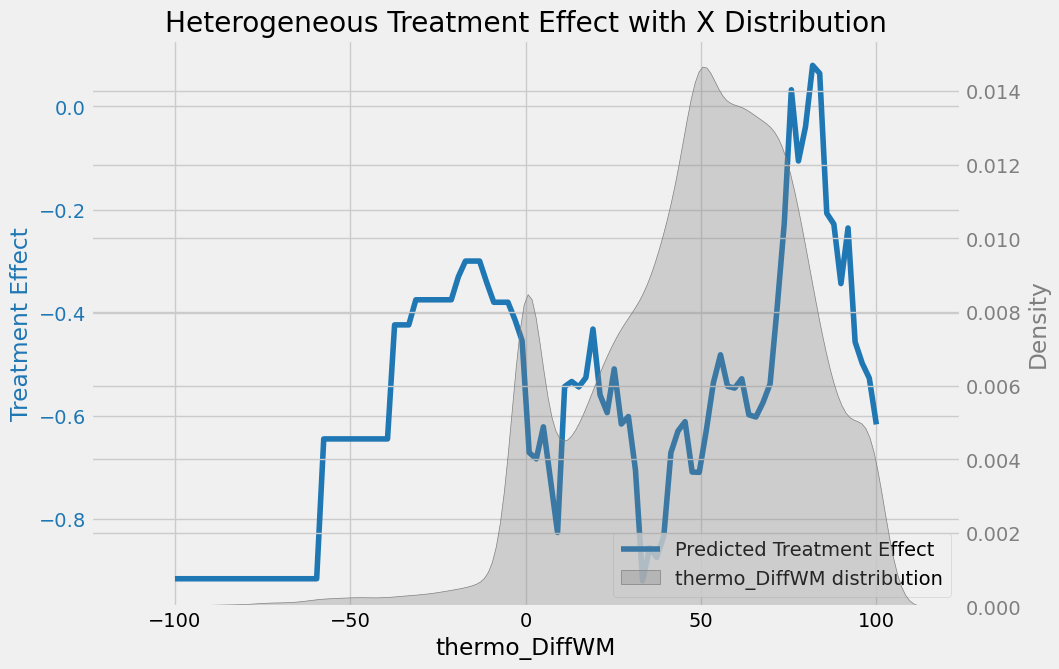

In [26]:
X_cols = X_encoded.columns

# Pick the variable to simulate
var_to_plot = "thermo_DiffWM"

# Range of values for this variable
x_values = np.linspace(X_encoded[var_to_plot].min(), X_encoded[var_to_plot].max(), 100)

# Create simulation dataframe with other features at mean
sim_df = pd.DataFrame({col: X_encoded[col].mean() for col in X_cols}, index=range(100))
sim_df[var_to_plot] = x_values

# Predict treatment effect using DML model
tau_hat = T_learner.predict(sim_df)

diff = tau_hat[:, 0] - tau_hat[:, 1]

# Plot treatment effect
fig, ax1 = plt.subplots(figsize=(10, 7))

color = "tab:blue"
ax1.plot(x_values, diff, color=color, label="Predicted Treatment Effect")
ax1.set_xlabel(var_to_plot)
ax1.set_ylabel("Treatment Effect", color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Plot distribution of X on a second y-axis
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
sns.kdeplot(X_encoded[var_to_plot], ax=ax2, color="tab:gray", fill=True, alpha=0.3, label=f"{var_to_plot} distribution")
ax2.set_ylabel("Density", color="tab:gray")
ax2.tick_params(axis='y', labelcolor="tab:gray")

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='lower right')

plt.title("Heterogeneous Treatment Effect with X Distribution")
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


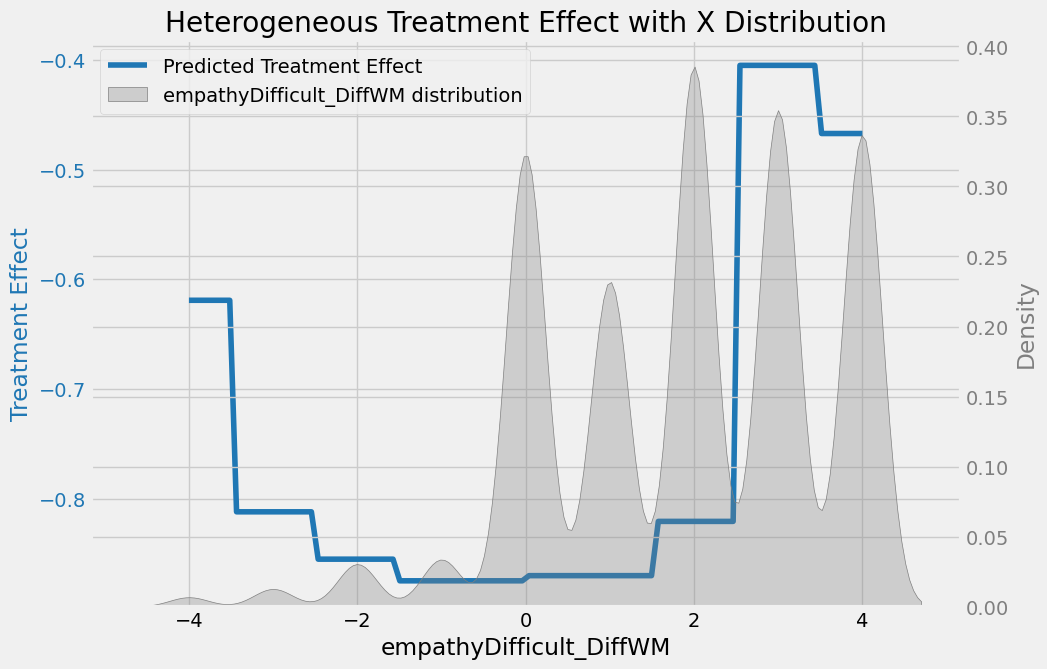

In [27]:
X_cols = X_encoded.columns

# Pick the variable to simulate
var_to_plot = "empathyDifficult_DiffWM"

# Range of values for this variable
x_values = np.linspace(X_encoded[var_to_plot].min(), X_encoded[var_to_plot].max(), 100)

# Create simulation dataframe with other features at mean
sim_df = pd.DataFrame({col: X_encoded[col].mean() for col in X_cols}, index=range(100))
sim_df[var_to_plot] = x_values

# Predict treatment effect using DML model
tau_hat = T_learner.predict(sim_df)

diff = tau_hat[:, 0] - tau_hat[:, 1]

# Plot treatment effect
fig, ax1 = plt.subplots(figsize=(10, 7))

color = "tab:blue"
ax1.plot(x_values, diff, color=color, label="Predicted Treatment Effect")
ax1.set_xlabel(var_to_plot)
ax1.set_ylabel("Treatment Effect", color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Plot distribution of X on a second y-axis
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
sns.kdeplot(X_encoded[var_to_plot], ax=ax2, color="tab:gray", fill=True, alpha=0.3, label=f"{var_to_plot} distribution")
ax2.set_ylabel("Density", color="tab:gray")
ax2.tick_params(axis='y', labelcolor="tab:gray")

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title("Heterogeneous Treatment Effect with X Distribution")
plt.show()

In [28]:
S_learner = BaseSRegressor(learner=LGBMRegressor(), control_name = "Control")

ate_s = S_learner.estimate_ate(X=X_encoded, treatment=T, y=Y)
ate_s

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000337 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 329
[LightGBM] [Info] Number of data points in the train set: 11363, number of used features: 37
[LightGBM] [Info] Start training from score -0.026783
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 330
[LightGBM] [Info] Number of data points in the train set: 11375, number of used features: 37
[LightGBM] [Info] Start training from score -0.010788


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


array([-0.02057571,  0.00298652])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


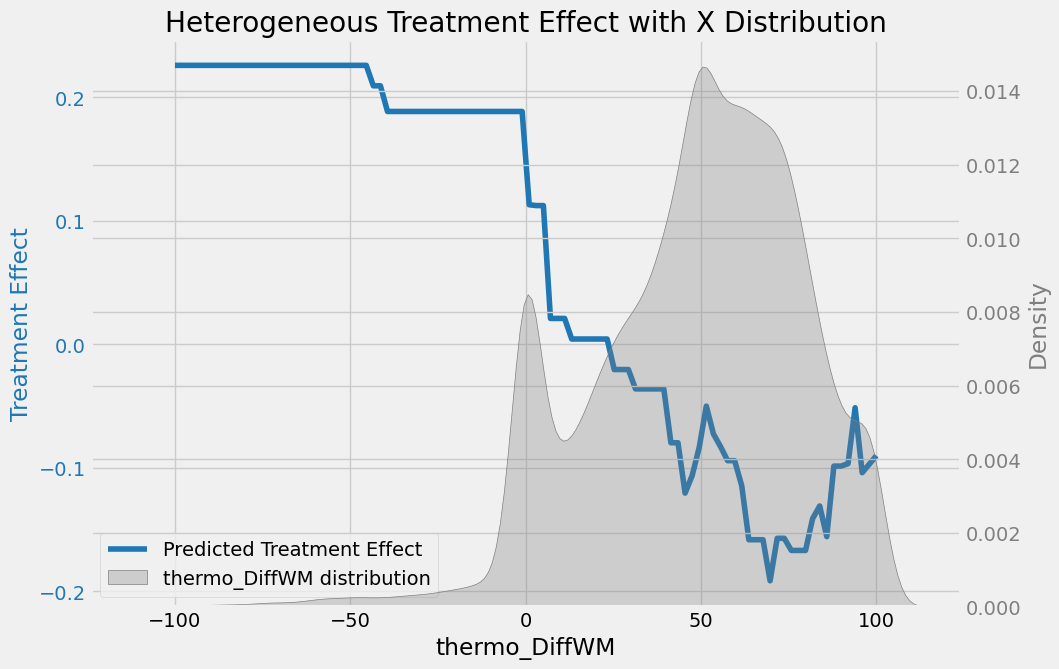

In [29]:
X_cols = X_encoded.columns

# Pick the variable to simulate
var_to_plot = "thermo_DiffWM"

# Range of values for this variable
x_values = np.linspace(X_encoded[var_to_plot].min(), X_encoded[var_to_plot].max(), 100)

# Create simulation dataframe with other features at mean
sim_df = pd.DataFrame({col: X_encoded[col].mean() for col in X_cols}, index=range(100))
sim_df[var_to_plot] = x_values

# Predict treatment effect using DML model
tau_hat = S_learner.predict(sim_df)

diff = tau_hat[:, 0] - tau_hat[:, 1]

# Plot treatment effect
fig, ax1 = plt.subplots(figsize=(10, 7))

color = "tab:blue"
ax1.plot(x_values, diff, color=color, label="Predicted Treatment Effect")
ax1.set_xlabel(var_to_plot)
ax1.set_ylabel("Treatment Effect", color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Plot distribution of X on a second y-axis
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
sns.kdeplot(X_encoded[var_to_plot], ax=ax2, color="tab:gray", fill=True, alpha=0.3, label=f"{var_to_plot} distribution")
ax2.set_ylabel("Density", color="tab:gray")
ax2.tick_params(axis='y', labelcolor="tab:gray")

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='lower left')

plt.title("Heterogeneous Treatment Effect with X Distribution")
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


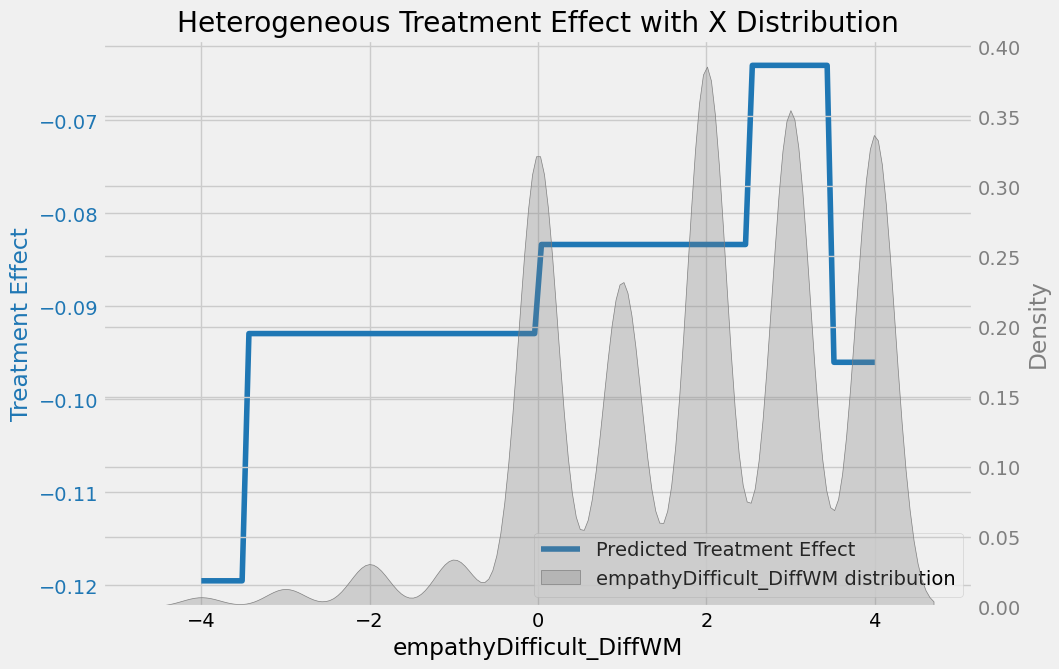

In [30]:
X_cols = X_encoded.columns

# Pick the variable to simulate
var_to_plot = "empathyDifficult_DiffWM"

# Range of values for this variable
x_values = np.linspace(X_encoded[var_to_plot].min(), X_encoded[var_to_plot].max(), 100)

# Create simulation dataframe with other features at mean
sim_df = pd.DataFrame({col: X_encoded[col].mean() for col in X_cols}, index=range(100))
sim_df[var_to_plot] = x_values

# Predict treatment effect using DML model
tau_hat = S_learner.predict(sim_df)

diff = tau_hat[:, 0] - tau_hat[:, 1]

# Plot treatment effect
fig, ax1 = plt.subplots(figsize=(10, 7))

color = "tab:blue"
ax1.plot(x_values, diff, color=color, label="Predicted Treatment Effect")
ax1.set_xlabel(var_to_plot)
ax1.set_ylabel("Treatment Effect", color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Plot distribution of X on a second y-axis
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
sns.kdeplot(X_encoded[var_to_plot], ax=ax2, color="tab:gray", fill=True, alpha=0.3, label=f"{var_to_plot} distribution")
ax2.set_ylabel("Density", color="tab:gray")
ax2.tick_params(axis='y', labelcolor="tab:gray")

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='lower right')

plt.title("Heterogeneous Treatment Effect with X Distribution")
plt.show()

In [31]:
X_learner = BaseXRegressor(learner=LGBMRegressor(), control_name = "Control")

ate_x, ate_x_lb, ate_x_ub = X_learner.estimate_ate(X=X_encoded, treatment=T, y=Y)
ate_x

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 325
[LightGBM] [Info] Number of data points in the train set: 5842, number of used features: 36
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000285 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 325
[LightGBM] [Info] Number of data points in the train set: 5521, number of used features: 36
[LightGBM] [Info] Start training from score -0.055124


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000522 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 325
[LightGBM] [Info] Number of data points in the train set: 5842, number of used features: 36
[LightGBM] [Info] Start training from score -0.027594
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 325
[LightGBM] [Info] Number of data points in the train set: 5521, number of used features: 36
[LightGBM] [Info] Start training from score -0.022873
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000334 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000331 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 325
[LightGBM] [Info] Number of data points in the train set: 5842, number of used features: 36
[LightGBM] [Info] Start training from score -0.000991
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000301 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 326
[LightGBM] [Info] Number of data points in the train set: 5533, number of used features: 36
[LightGBM] [Info] Start training from score 0.005134


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packag

array([-0.02602577,  0.00287636])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


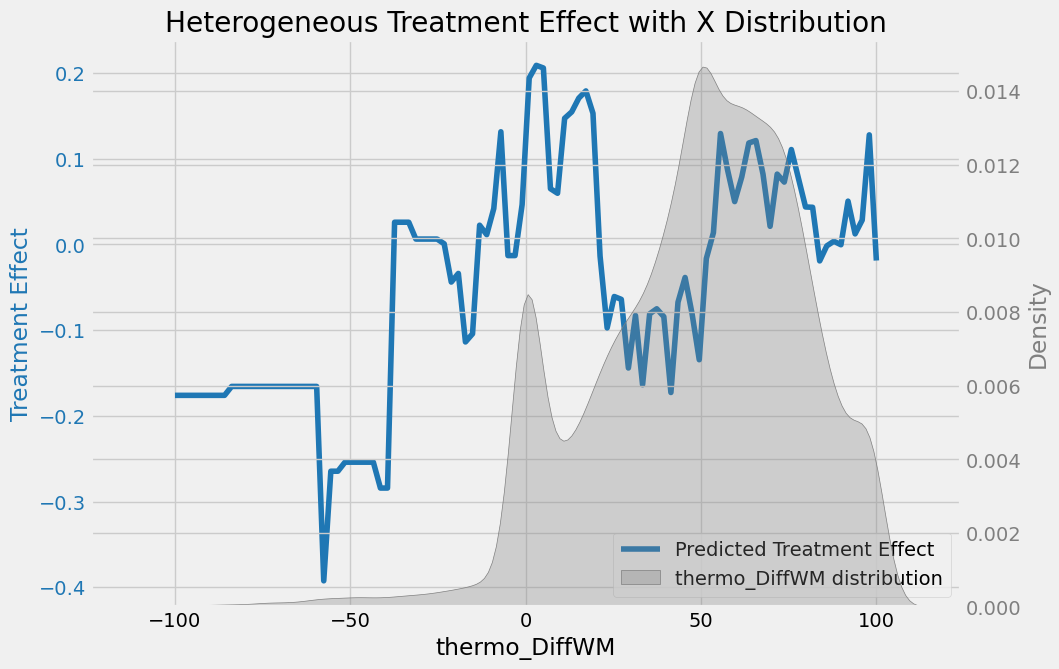

In [32]:
X_cols = X_encoded.columns

# Pick the variable to simulate
var_to_plot = "thermo_DiffWM"

# Range of values for this variable
x_values = np.linspace(X_encoded[var_to_plot].min(), X_encoded[var_to_plot].max(), 100)

# Create simulation dataframe with other features at mean
sim_df = pd.DataFrame({col: X_encoded[col].mean() for col in X_cols}, index=range(100))
sim_df[var_to_plot] = x_values

# Predict treatment effect using DML model
tau_hat = X_learner.predict(sim_df)

diff = tau_hat[:, 0] - tau_hat[:, 1]

# Plot treatment effect
fig, ax1 = plt.subplots(figsize=(10, 7))

color = "tab:blue"
ax1.plot(x_values, diff, color=color, label="Predicted Treatment Effect")
ax1.set_xlabel(var_to_plot)
ax1.set_ylabel("Treatment Effect", color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Plot distribution of X on a second y-axis
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
sns.kdeplot(X_encoded[var_to_plot], ax=ax2, color="tab:gray", fill=True, alpha=0.3, label=f"{var_to_plot} distribution")
ax2.set_ylabel("Density", color="tab:gray")
ax2.tick_params(axis='y', labelcolor="tab:gray")

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='lower right')

plt.title("Heterogeneous Treatment Effect with X Distribution")
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


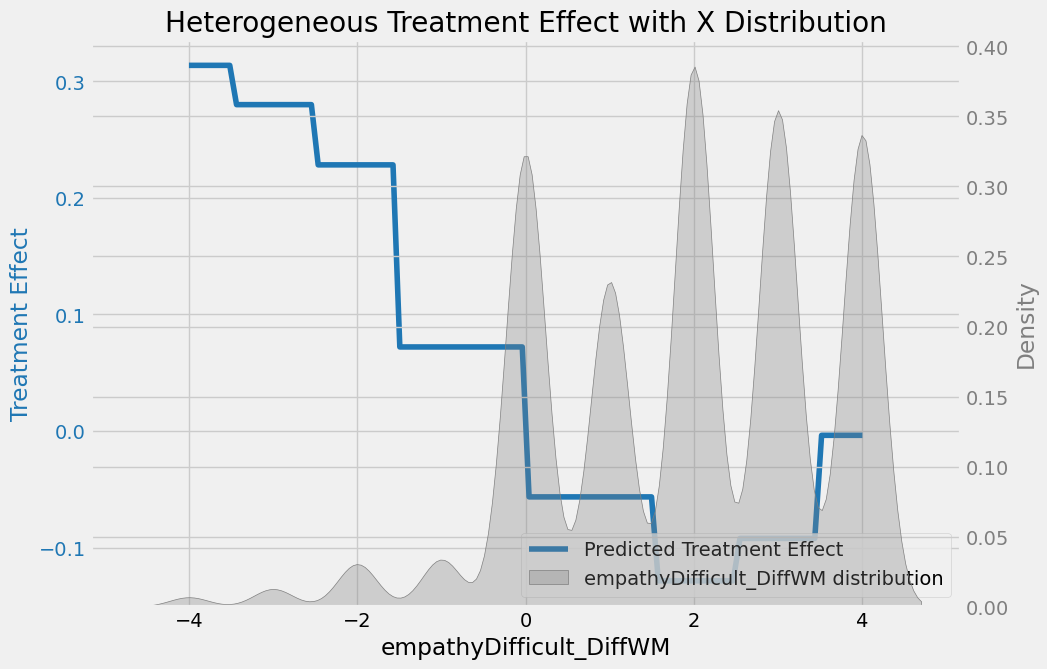

In [33]:
X_cols = X_encoded.columns

# Pick the variable to simulate
var_to_plot = "empathyDifficult_DiffWM"

# Range of values for this variable
x_values = np.linspace(X_encoded[var_to_plot].min(), X_encoded[var_to_plot].max(), 100)

# Create simulation dataframe with other features at mean
sim_df = pd.DataFrame({col: X_encoded[col].mean() for col in X_cols}, index=range(100))
sim_df[var_to_plot] = x_values

# Predict treatment effect using DML model
tau_hat = X_learner.predict(sim_df)

diff = tau_hat[:, 0] - tau_hat[:, 1]

# Plot treatment effect
fig, ax1 = plt.subplots(figsize=(10, 7))

color = "tab:blue"
ax1.plot(x_values, diff, color=color, label="Predicted Treatment Effect")
ax1.set_xlabel(var_to_plot)
ax1.set_ylabel("Treatment Effect", color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Plot distribution of X on a second y-axis
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
sns.kdeplot(X_encoded[var_to_plot], ax=ax2, color="tab:gray", fill=True, alpha=0.3, label=f"{var_to_plot} distribution")
ax2.set_ylabel("Density", color="tab:gray")
ax2.tick_params(axis='y', labelcolor="tab:gray")

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='lower right')

plt.title("Heterogeneous Treatment Effect with X Distribution")
plt.show()